<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab5/blob/main/DP/logistic_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic map

H. Gould, J. Tobochnik An Introduction to Conputer Simulation Methods, Ch6. The Chaotic Motion of Dynamical Systems 2nd Ed. 1996


$$
x_{n+1} = f(x_n) = 4 r x_n (1-x_n)
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [68]:
%%time
MEMORY = 16
def logistic(x, r):
  return 4 * r * x * ( 1- x)

# The global 'trajectory = np.array([0])' is no longer needed as the iterate function now handles its own state.

def iterate(x_start, r, tolerance=9, max_steps=10000):
  # Initialize the trajectory list with the initial seed value (e.g., 0 from the original code)
  trajectory_list = [np.round(x_start, tolerance)]
  current_x = x_start # The value to pass to the logistic function for the next iteration

  for _ in range(max_steps):
    next_x = logistic(current_x, r)
    next_x_rounded = np.round(next_x, tolerance)

    if next_x_rounded in trajectory_list:
      # Found a repeating value (within tolerance), break the loop
      break
    else:
      trajectory_list.append(next_x_rounded)
      current_x = next_x # Update current_x for the next iteration
  trajectory =   np.array(trajectory_list)
  return np.unique(np.round(trajectory[-MEMORY:], tolerance-3))



CPU times: user 92 µs, sys: 0 ns, total: 92 µs
Wall time: 97 µs


CPU times: user 1min 44s, sys: 681 ms, total: 1min 44s
Wall time: 1min 45s


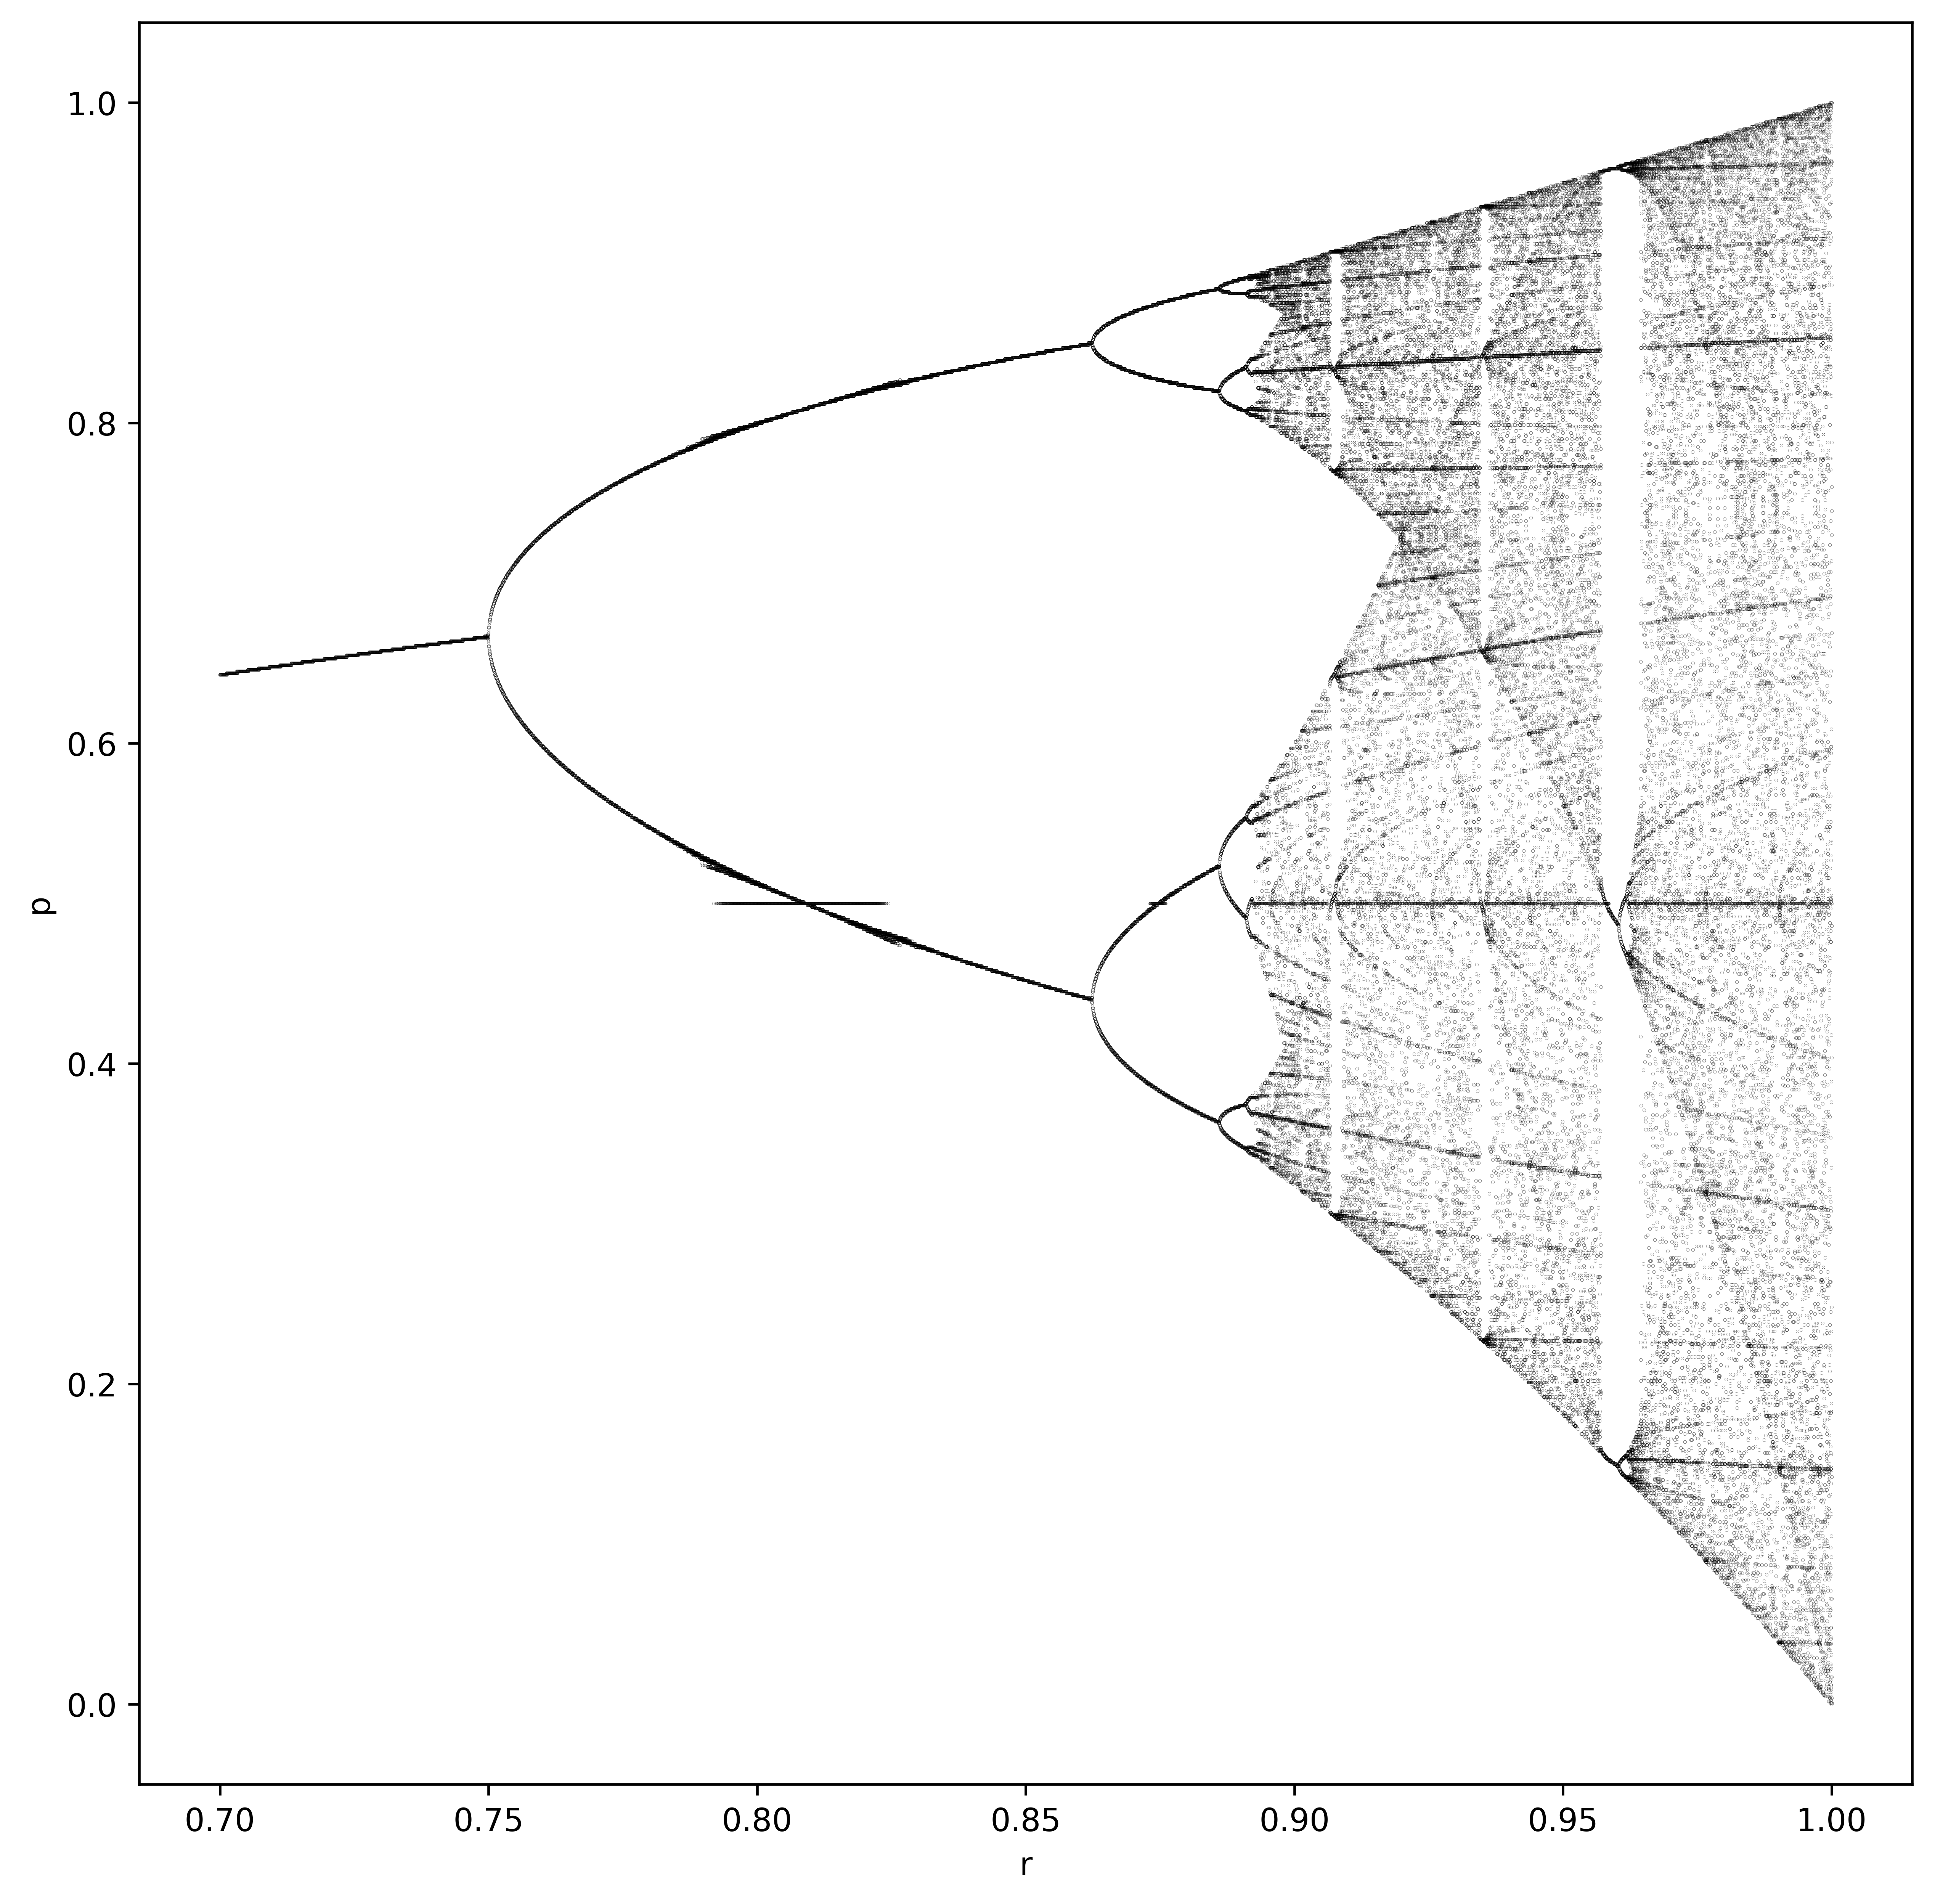

In [88]:
%%time
tolerance = 6
x0 = 0.5
rs = np.linspace(0.7, 1, 10000)

fig, ax = plt.subplots(figsize=(10, 10), dpi=600)
ax.set_xlabel('r')
ax.set_ylabel('p')
for r in rs:
    points = iterate(x0, r, tolerance=tolerance)
    for point in points:
      plt.plot(r, point, '.', color='black', ms=0.1)


## Lyapunov exponent for the logistic map

$$
|\Delta x_n| = |\Delta x_0| e^{\lambda n},
$$
$$
\lambda = \frac{1}{n}\ln\left| \frac{\Delta x_n}{\Delta x_0}\right|, \quad \frac{\Delta x_n}{\Delta x_0} = \frac{\Delta x_1}{\Delta x_0} \frac{\Delta x_2}{\Delta x_1} \cdots \frac{\Delta x_n}{\Delta x_{n-1}}
$$
Therefore
$$
\lambda = \frac{1}{n} \sum_{n-1}^{i=0} \ln \left| \frac{\Delta x_{i+1}}{\Delta x_i}\right| \approx \frac{1}{n} \sum_{n-1}^{i=0} \ln \left| f'(x_i) \right|
$$
For logistic map
$$
f'(x_i) = 4 r (1-2x_i).
$$




In [74]:
%%time
MEMORY = 16
def logistic(x, r):
  return 4 * r * x * ( 1- x)

def logistic_derivative(x, r):
  return 4 * r * (1-2 * x)

 # 1e5
def lyapunov(x_start, r, N=100000, skipfirst=1000):
  x = np.zeros(N)
  d = np.zeros(N)
  x[0] = x_start
  d[0] = 0
  for i in range(1, N):
    x[i] = logistic(x[i-1], r)
    fprime = np.abs(logistic_derivative(x[i-1], r))
    if fprime > 0:
      d[i] = np.log(fprime)
    else:
      d[i] = 0

  return np.mean(d[skipfirst:])

lyapunov(0.5, 0.8, N=100000, skipfirst=1000)



CPU times: user 328 ms, sys: 986 µs, total: 329 ms
Wall time: 330 ms


np.float64(-0.9162907318741619)

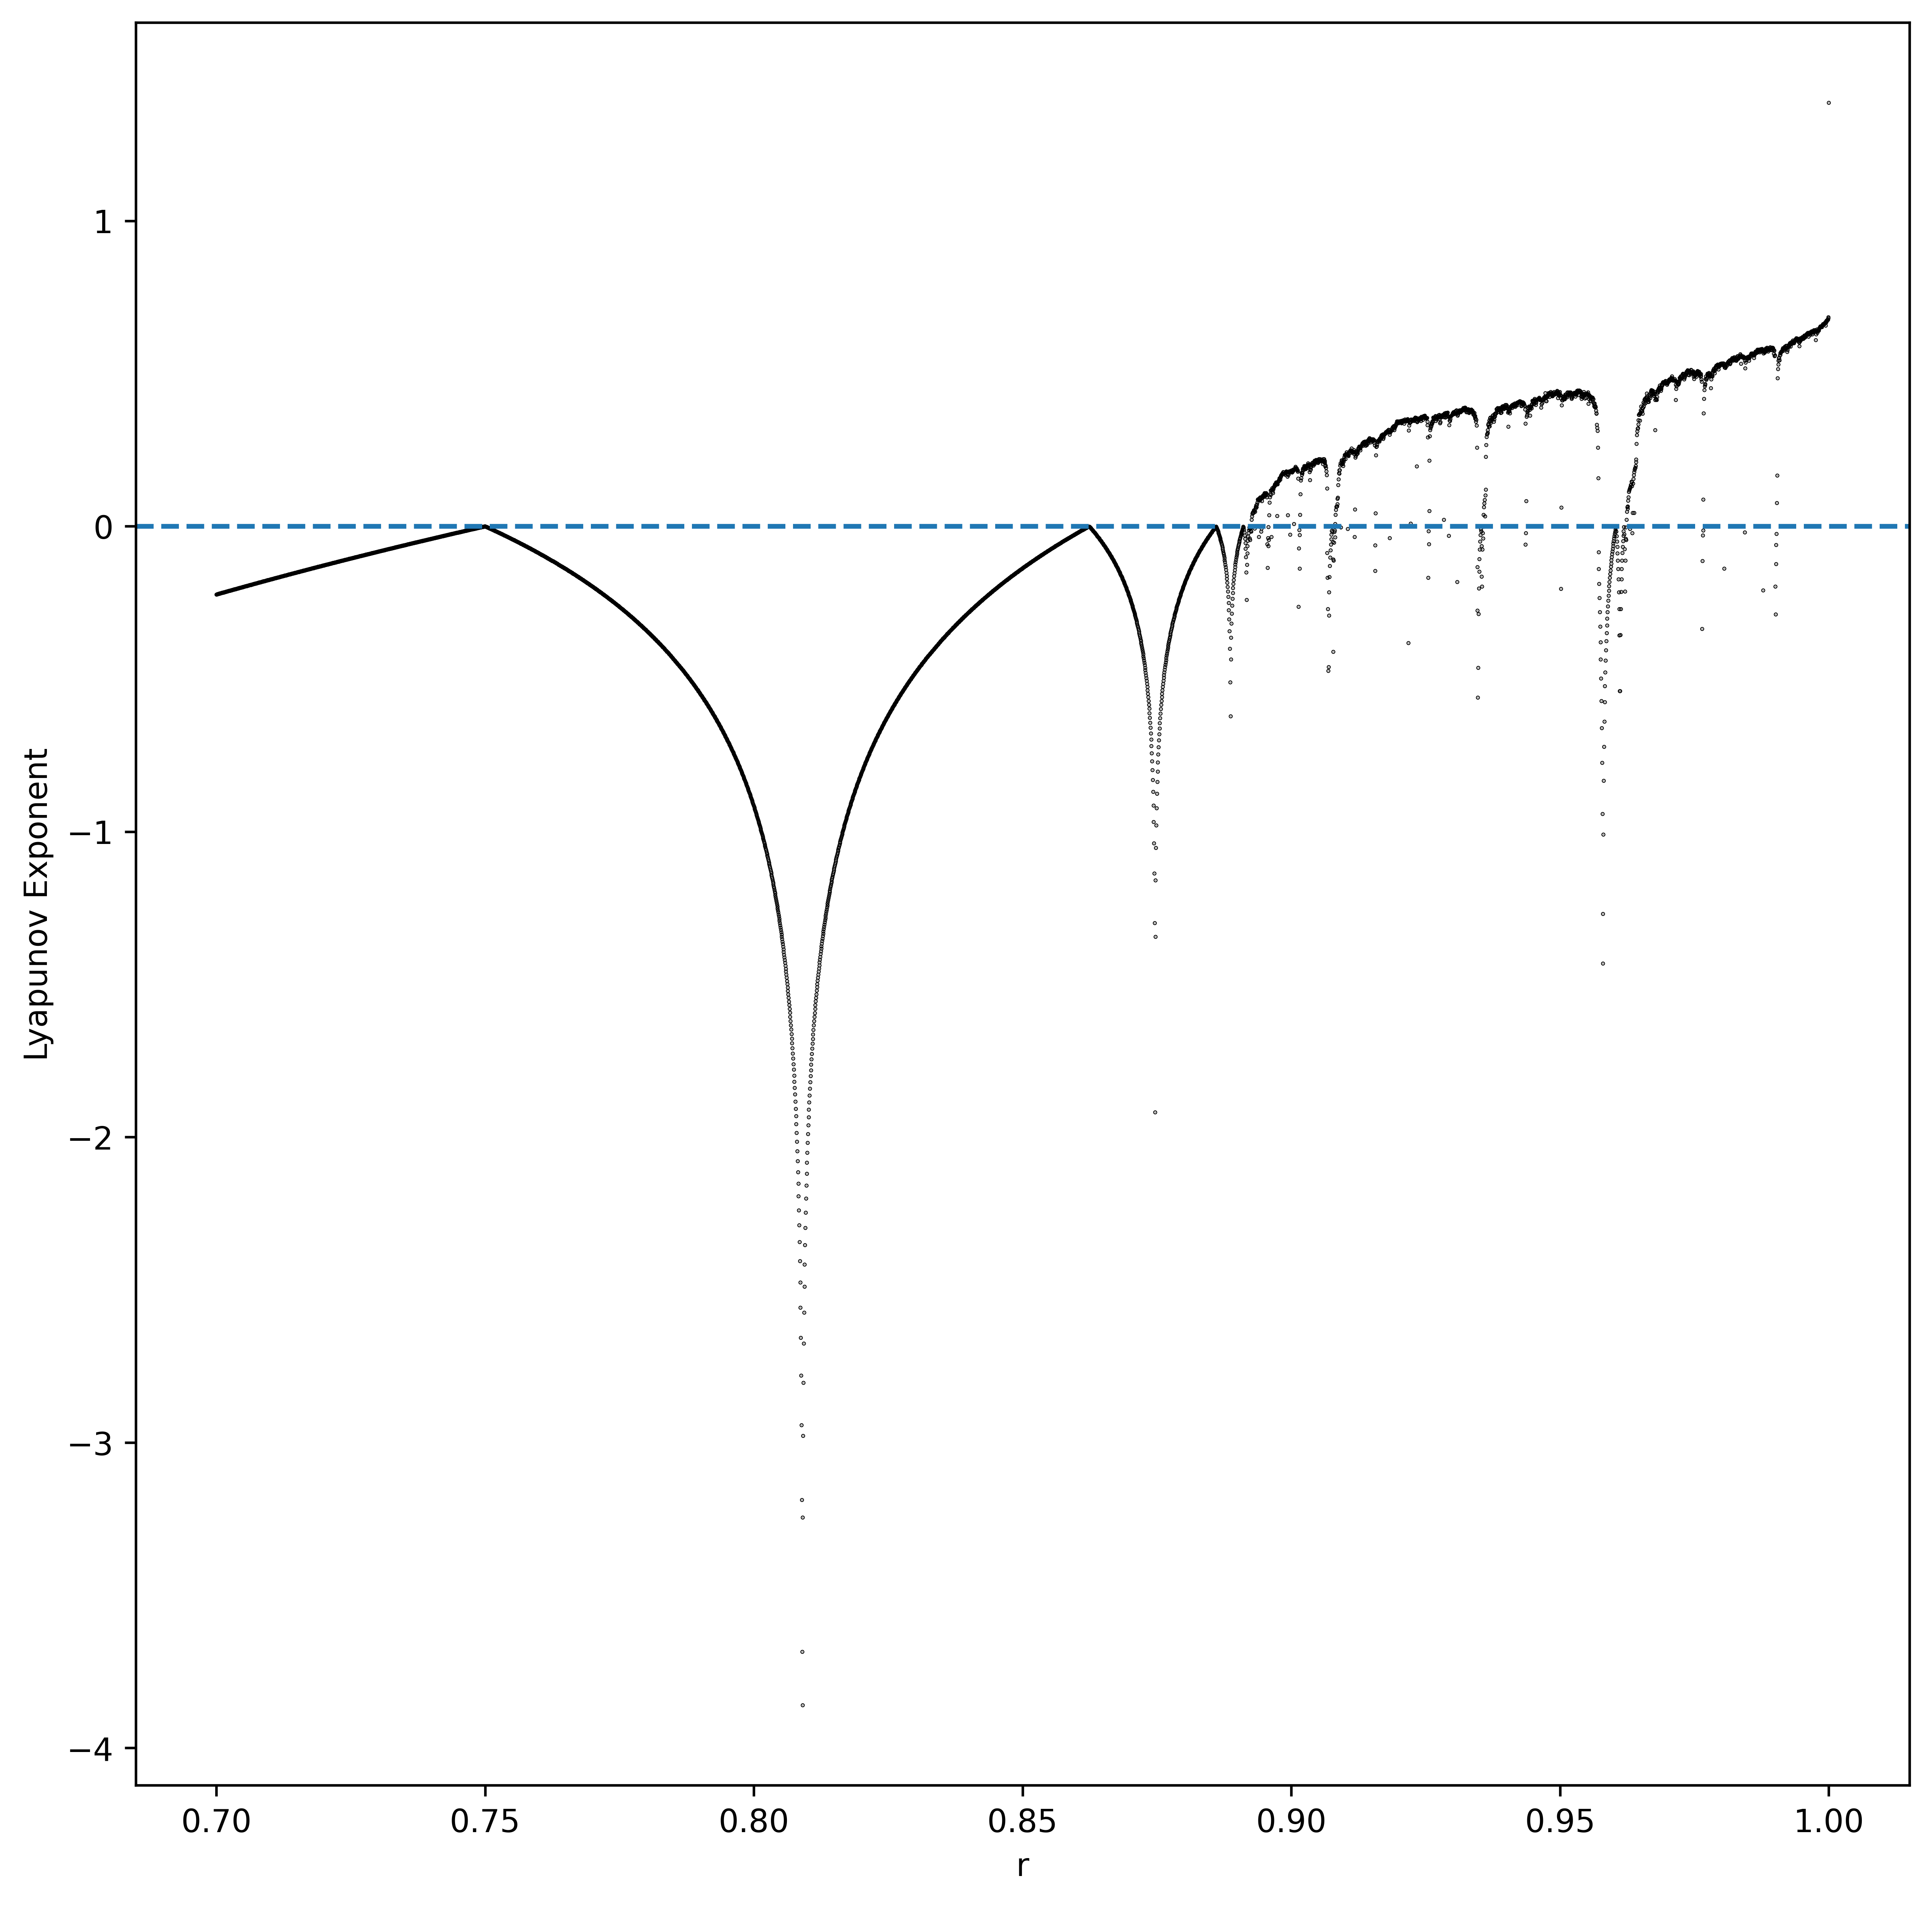

In [87]:
rs = np.linspace(0.7, 1, 5000)

fig, ax = plt.subplots(figsize=(10, 10), dpi=600)
ax.set_xlabel('r')
ax.set_ylabel('Lyapunov Exponent')
for r in rs:
    l = lyapunov(0.5, r, N=10000, skipfirst=1000)
    plt.plot(r, l, '.', color='black', ms=0.5)
plt.axhline(0, ls='--')